In [ ]:
#importing necessary modules
#update example for github
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [19]:
#defining constants
REGION_COUNTRY_COLORS = {
    # --- NORTH AMERICA (Crimson Red) ---
    'USA': '#C8102E', 'CAN': '#C8102E', 'MEX': '#C8102E',

    # --- SOUTH / CENTRAL AMERICA (Emerald Green) ---
    'CHL': '#009739', 'BRA': '#009739',

    # --- WESTERN & NORTHERN EUROPE (Royal Blue) ---
    'AUT': '#0055A5', 'BEL': '#0055A5', 'DNK': '#0055A5', 'FIN': '#0055A5',
    'FRA': '#0055A5', 'DEU': '#0055A5', 'ISL': '#0055A5', 'IRL': '#0055A5',
    'LUX': '#0055A5', 'NLD': '#0055A5', 'NOR': '#0055A5', 'SWE': '#0055A5',
    'CHE': '#0055A5', 'GBR': '#0055A5',

    # --- SOUTHERN EUROPE & MEDITERRANEAN (Warm Gold) ---
    'GRC': '#EAA800', 'ITA': '#EAA800', 'PRT': '#EAA800', 'ESP': '#EAA800',
    'ISR': '#EAA800', 'TUR': '#EAA800',

    # --- EASTERN EUROPE (Deep Purple) ---
    'CZE': '#6A1B9A', 'EST': '#6A1B9A', 'HUN': '#6A1B9A', 'POL': '#6A1B9A',
    'SVK': '#6A1B9A', 'SVN': '#6A1B9A', 'RUS': '#6A1B9A',

    # --- ASIA (Vibrant Orange) ---
    'CHN': '#FF6F00', 'IND': '#FF6F00', 'IDN': '#FF6F00', 'JPN': '#FF6F00', 
    'KOR': '#FF6F00',

    # --- OCEANIA (Teal) ---
    'AUS': '#00838F', 'NZL': '#00838F', 'ZAF': '#00838F' # (Note: ZAF/South Africa added here or treated as Rest of World)
}

REGION_LABELS = {
    'North America': '#C8102E',
    'South America': '#009739',
    'West / North Europe': '#0055A5',
    'South Europe / Mediterranean': '#EAA800',
    'Eastern Europe': '#6A1B9A',
    'Asia': '#FF6F00',
    'Oceania & Africa': '#00838F'
}

GDP_COUNTRY_COLORS = {
    # --- TIER 1: Mega Economies (>$2 Trillion) -> Deep Navy Blue ---
    'USA': '#0A2540', 'CHN': '#0A2540', 'DEU': '#0A2540', 'JPN': '#0A2540', 
    'IND': '#0A2540', 'GBR': '#0A2540', 'FRA': '#003366', 'BRA': '#0A2540',
    'ITA': '#0A2540', 'CAN': '#0A2540',

    # --- TIER 2: Large Economies ($500B - $2 Trillion) -> Slate Blue ---
    'RUS': '#4A90E2', 'MEX': '#4A90E2', 'AUS': '#4A90E2', 'KOR': '#4A90E2', 
    'ESP': '#4A90E2', 'IDN': '#4A90E2', 'NLD': '#4A90E2', 'TUR': '#4A90E2', 
    'CHE': '#4A90E2', 'SWE': '#4A90E2', 'POL': '#4A90E2', 'BEL': '#4A90E2',

    # --- TIER 3: Medium Economies ($200B - $500B) -> Muted Teal ---
    'AUT': '#00A896', 'IRL': '#00A896', 'ISR': '#00A896', 'NOR': '#00A896', 
    'DNK': '#00A896', 'CHL': '#00A896', 'ZAF': '#00A896', 'FIN': '#00A896', 
    'CZE': '#00A896', 'PRT': '#00A896', 'NZL': '#00A896', 'GRC': '#00A896',

    # --- TIER 4: Small Economies (<$200B) -> Light Slate Grey ---
    'HUN': '#94A3B8', 'SVK': '#94A3B8', 'LUX': '#94A3B8', 'SVN': '#94A3B8', 
    'EST': '#94A3B8', 'ISL': '#94A3B8'
}

GDP_LABELS = {
    'Mega': '#0A2540',
    'Large': '#4A90E2',
    'Medium': '#00A896',
    'Small': '#94A3B8'
}

In [20]:
#reading files
aamne_df = pd.read_csv("data/AAMNE.csv")
eps_df = pd.read_csv("data/EPS.csv")
wef_df = pd.read_csv("data/WEF_GCI.csv")
ccpi_df = pd.read_csv("data/CCPI.csv")


In [ ]:
#pre-processing function for aamne dataset
def preprocess_aamne(industry, ownership=None):
    #filtering eps countries in aamne dataset
    filtered_aamne_df:pd.DataFrame = aamne_df[aamne_df["cou"].isin(eps_df["REF_AREA"].unique())]

    #filtering industry
    filtered_aamne_df = filtered_aamne_df[filtered_aamne_df["isic"]==industry]

    #filtering domestic or foreign investments
    if ownership != None:
        filtered_aamne_df = filtered_aamne_df[filtered_aamne_df["own"]==ownership]

    else: #if the ownership is not given, sum domestic and foreign investments
        filtered_aamne_df = filtered_aamne_df.groupby(["year", "cou"])["GVA"].sum().reset_index()

    #assiging region and gpd labels
    for idx, item in filtered_aamne_df.iterrows():
        country_color =  REGION_COUNTRY_COLORS.get(item["cou"])
        for region, color_value in REGION_LABELS.items():
            if color_value == country_color:
                filtered_aamne_df.at[idx, "Region"] = region
                break
        
        country_color = GDP_COUNTRY_COLORS.get(item["cou"])
        for gdp_tier, color_value in GDP_LABELS.items():
            if color_value == country_color:
                filtered_aamne_df.at[idx, "GDP_Tier"] = gdp_tier
                break

    return filtered_aamne_df

#pre-processing function for eps dataset
def preprocess_eps():
    #filtering years 
    filtered_eps_df = eps_df[eps_df["TIME_PERIOD"].isin(range(2000,2020+1))]

    #filtering climate policy
    filtered_eps_df = filtered_eps_df[filtered_eps_df["CLIM_POL"]=="EPS"]

    #assiging region and gpd labels
    for idx, item in filtered_eps_df.iterrows():
        country_color =  REGION_COUNTRY_COLORS.get(item["REF_AREA"])
        for region, color_value in REGION_LABELS.items():
            if color_value == country_color:
                filtered_eps_df.at[idx, "Region"] = region
                break
        
        country_color = GDP_COUNTRY_COLORS.get(item["REF_AREA"])
        for gdp_tier, color_value in GDP_LABELS.items():
            if color_value == country_color:
                filtered_eps_df.at[idx, "GDP_Tier"] = gdp_tier
                break

    return filtered_eps_df

#pre-processing function wef dataset
def preprocess_wef():
    pass

#helper function to get country data from the dataframes
def fetch_country_data(aamne_df, eps_df, country_code):
    return aamne_df[aamne_df["cou"]==country_code], eps_df[eps_df["REF_AREA"]==country_code]


IndentationError: expected an indented block (948738394.py, line 61)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/per-country/B05T09-AUS-GVA-vs-OBS.png'

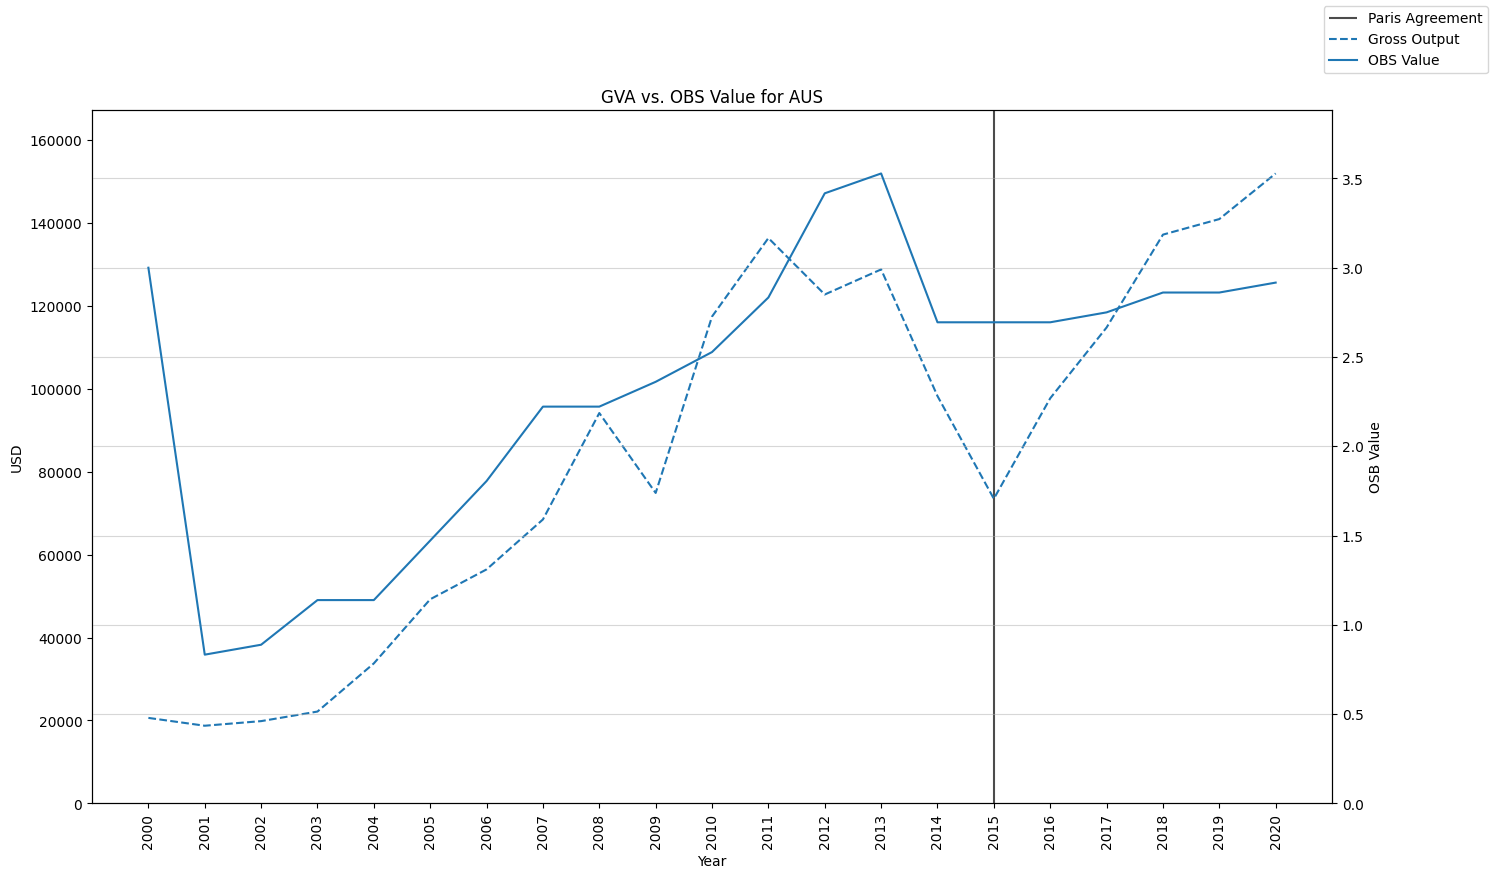

In [ ]:
# function to plot for a country
def single_plot(aamne_data, eps_data, title, filepath=None, show=False):
    X = aamne_data["year"].unique()

    fig, ax1 = plt.subplots()
    fig.set_size_inches(16,9)
    plt.title(title)
    plt.xticks(aamne_data["year"].unique(), rotation=90)
    ax2 = ax1.twinx()

    ax1.set_xlabel("Year")
    ax1.set_ylabel("USD")
    ax1.set_ylim(0, aamne_data["GVA"].max()*1.1)

    ax2.set_ylabel("OSB Value")
    ax2.set_ylim(0, eps_data["OBS_VALUE"].max()*1.1)

    ax1.vlines([2015], 0, aamne_data["GVA"].max()*1.1,
               label="Paris Agreement", linestyles="solid", alpha=0.7, color="black")
    ax1.plot(X, aamne_data["GVA"],
             label="Gross Output", linestyle="dashed", alpha=1.0)
    ax2.plot(X, eps_data["OBS_VALUE"],
             label="OBS Value", linestyle="solid", alpha=1.0)

    fig.legend()
    plt.grid(True, alpha=0.5)
    if filepath != None:
        plt.savefig(filepath)
    if show:
        plt.show()
    plt.close()

def draw_plot_for_each_country(industry, ownership=None):
    preprocessed_aamne = preprocess_aamne(industry, ownership)
    preprocessed_eps   = preprocess_eps()
    for country_code in eps_df["REF_AREA"].unique():
        country_aamne, country_eps = fetch_country_data(preprocessed_aamne, preprocessed_eps, country_code)
        single_plot(country_aamne, country_eps,
                    f"GVA vs. OBS Value for {country_code}",
                    f"figures/per-country/{industry}-{country_code}-GVA-vs-OBS.png")

draw_plot_for_each_country("B05T09")

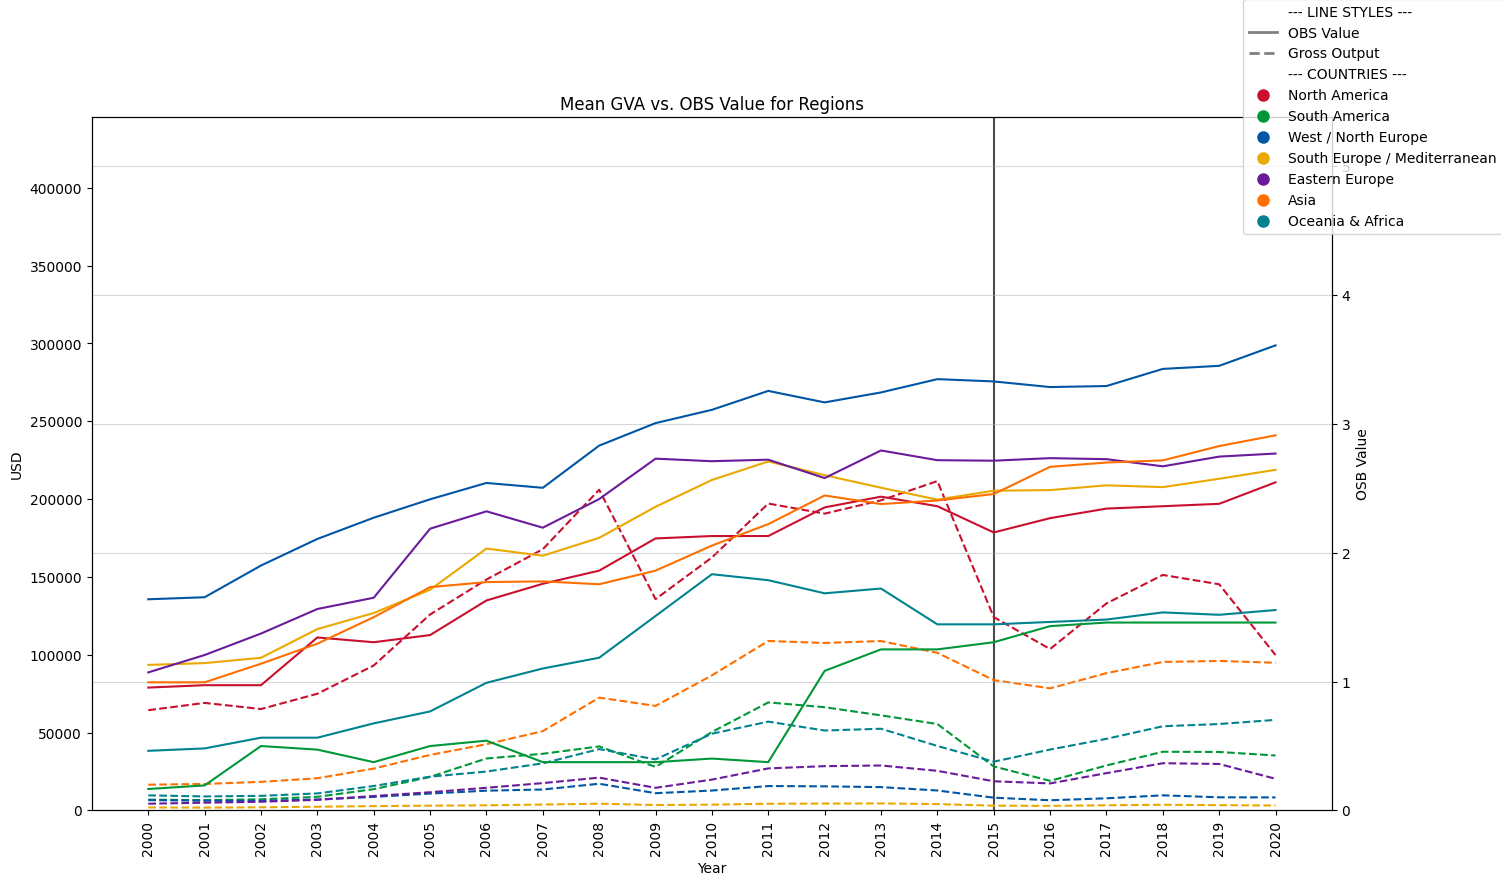

In [ ]:
# function to plot by grouping
def group_plot(aamne_data, eps_data, title, grouping_name, filepath=None, show=False):
    X = aamne_data["year"].unique()

    fig, ax1 = plt.subplots()
    fig.set_size_inches(16,9)
    plt.title(title)
    plt.xticks(aamne_data["year"].unique(), rotation=90)
    ax2 = ax1.twinx()

    ax1.set_xlabel("Year")
    ax1.set_ylabel("USD")
    ax1.set_ylim(0, aamne_data["GVA"].max()*1.1)

    ax2.set_ylabel("OSB Value")
    ax2.set_ylim(0, eps_data["OBS_VALUE"].max()*1.1)

    ax1.vlines([2015], 0, aamne_data["GVA"].max()*1.1,
               label="Paris Agreement", linestyles="solid", alpha=0.7, color="black")
    
    if grouping_name == "region":
        group_data_field = "Region"
        group_labels = REGION_LABELS

    elif grouping_name == "gdp":
        group_data_field = "GDP_Tier"
        group_labels = GDP_LABELS

    else:
        group_data_field = None
        group_labels = None

    mean_GVA_df = aamne_data.groupby(["year", group_data_field])["GVA"].mean().reset_index()
    std_GVA_df = aamne_data.groupby(["year", group_data_field])["GVA"].std().reset_index()

    mean_OBS_df = eps_data.groupby(["TIME_PERIOD", group_data_field])["OBS_VALUE"].mean().reset_index()
    std_OBS_df = eps_data.groupby(["TIME_PERIOD", group_data_field])["OBS_VALUE"].std().reset_index()

    for group_name, color_value in group_labels.items():
        #drawing plots of GVA for each cluster

        region_data = mean_GVA_df[mean_GVA_df[group_data_field]==group_name]["GVA"]
        region_std = std_GVA_df[std_GVA_df[group_data_field]==group_name]["GVA"]
        ax1.plot(X, region_data, label=f"GVA of {group_name}", color=color_value, linestyle="dashed", alpha=1.0)
        #ax1.errorbar(X, region_data, region_std*0.05, label=f"GVA of {group_name}", color=color_value, linestyle="dashed", alpha=1.0)

        #drawing plots of OBS_VALUE for each cluster
        region_data = mean_OBS_df[mean_OBS_df[group_data_field]==group_name]["OBS_VALUE"]
        region_std = std_OBS_df[std_OBS_df[group_data_field]==group_name]["OBS_VALUE"]
        ax2.plot(X, region_data, label=f"OBS Value of {group_name}", color=color_value, linestyle="solid", alpha=1.0)
        #ax2.errorbar(X, region_data, region_std*0.05, label=f"OBS Value of {group_name}", color=color_value, linestyle="solid", alpha=1.0)

    # Step A: Create handles for the line styles
    style_handles = [
        Line2D([0], [0], color='gray', linestyle='-', lw=2, label="OBS Value"),
        Line2D([0], [0], color='gray', linestyle='--', lw=2, label="GVA Value")
    ]

    # Step B: Create handles for the country colors
    color_handles = [
        Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=country)
        for country, color in group_labels.items()
    ]

    # Step C: Combine them into a single legend (or separate them)
    # To display them clearly, we can combine them and add title headers using an empty handle
    legend_handles = (
        [Line2D([0], [0], color='none', label='--- LINE STYLES ---')] + style_handles +
        [Line2D([0], [0], color='none', label='--- COUNTRIES ---')] + color_handles
    )

    fig.legend(handles=legend_handles, borderaxespad=0)
    plt.grid(True, alpha=0.5)
    if filepath != None:
        plt.savefig(filepath)
    if show:
        plt.show()
    plt.close()

def draw_plots_by_grouping(industry, ownership=None):
    preprocessed_aamne = preprocess_aamne(industry, ownership)
    preprocessed_eps   = preprocess_eps()
    group_plot(preprocessed_aamne, preprocessed_eps,
               "Mean GVA vs. OBS Value for Regions",
               "region",
               f"figures/grouped-countries/{industry}-Regions-GVA-vs-OBS")
    
draw_plots_by_grouping("B05T09")